# Problem Statment

Taken survey results in the past 3 days in a specific state in U.S., then predict the percentage of new tested positive cases in the 3rd day.

In [1]:
#load the datsets from the csv file using pandas
import pandas as pd

data_frame_test = pd.read_csv("covid.test.csv")
data_frame_train = pd.read_csv("covid.train.csv")

# Exploratory Data Analysis

In [2]:
#display data
display(data_frame_test)
display(data_frame_train)

,id,AL,AK,AZ,AR,CA,CO,CT,FL,GA,...,shop.2,restaurant.2,spent_time.2,large_event.2,public_transit.2,anxious.2,depressed.2,felt_isolated.2,worried_become_ill.2,worried_finances.2
0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,52.071090,8.624001,29.374792,5.391413,2.754804,19.695098,13.685645,24.747837,66.194950,44.873473
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,58.742461,21.720187,41.375784,9.450179,3.150088,22.075715,17.302077,23.559622,57.015009,38.372829
2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,59.109045,20.123959,40.072556,8.781522,2.888209,23.920870,18.342506,24.993341,55.291498,38.907257
3,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,55.442267,16.083529,36.977612,5.199286,2.575347,21.073800,12.087171,18.608723,67.036197,43.142779
4,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,60.588783,19.503010,42.631236,11.549771,8.530551,15.896575,11.781634,15.065228,61.196518,43.574676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888,888,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,56.762931,21.494159,44.202567,14.996865,2.291745,17.740003,12.822676,18.123344,60.417531,37.156229
889,889,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,57.888461,16.770893,37.373472,7.169675,2.631595,20.587449,15.960166,23.710310,58.758735,38.673787
890,890,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,57.589848,16.761311,36.874822,11.046907,1.912310,16.800220,13.280423,22.423640,60.934851,43.122513
891,891,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,57.966384,22.696669,45.350415,20.343487,2.385330,16.528265,15.092539,17.476063,54.862386,44.016255


,id,AL,AK,AZ,AR,CA,CO,CT,FL,GA,...,restaurant.2,spent_time.2,large_event.2,public_transit.2,anxious.2,depressed.2,felt_isolated.2,worried_become_ill.2,worried_finances.2,tested_positive.2
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.812411,43.430423,16.151527,1.602635,15.409449,12.088688,16.702086,53.991549,43.604229,20.704935
1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.682974,43.196313,16.123386,1.641863,15.230063,11.809047,16.506973,54.185521,42.665766,21.292911
2,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.593983,43.362200,16.159971,1.677523,15.717207,12.355918,16.273294,53.637069,42.972417,21.166656
3,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,22.576992,42.954574,15.544373,1.578030,15.295650,12.218123,16.045504,52.446223,42.907472,19.896607
4,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,22.091433,43.290957,15.214655,1.641667,14.778802,12.417256,16.134238,52.560315,43.321985,20.178428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2695,2695,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,15.090116,30.839219,7.849525,1.760094,14.617563,11.163213,18.742673,68.024690,38.920206,13.008853
2696,2696,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.779264,30.617100,7.754800,1.780730,14.513419,11.281241,18.539741,67.855755,39.224244,12.725638
2697,2697,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.961085,30.595194,7.744075,1.921828,14.160990,11.163526,18.702564,67.731162,38.740651,12.613441
2698,2698,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.609582,30.420998,7.687974,1.992580,14.409427,11.330301,19.134697,67.795100,38.595125,12.477227


In [3]:
#getting known with column names for traning data
column_names = data_frame_train.columns.tolist()

# Print the column names
print(column_names)


['id', 'AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'FL', 'GA', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'MD', 'MA', 'MI', 'MN', 'MS', 'MO', 'NE', 'NV', 'NJ', 'NM', 'NY', 'NC', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'TX', 'UT', 'VA', 'WA', 'WV', 'WI', 'cli', 'ili', 'hh_cmnty_cli', 'nohh_cmnty_cli', 'wearing_mask', 'travel_outside_state', 'work_outside_home', 'shop', 'restaurant', 'spent_time', 'large_event', 'public_transit', 'anxious', 'depressed', 'felt_isolated', 'worried_become_ill', 'worried_finances', 'tested_positive', 'cli.1', 'ili.1', 'hh_cmnty_cli.1', 'nohh_cmnty_cli.1', 'wearing_mask.1', 'travel_outside_state.1', 'work_outside_home.1', 'shop.1', 'restaurant.1', 'spent_time.1', 'large_event.1', 'public_transit.1', 'anxious.1', 'depressed.1', 'felt_isolated.1', 'worried_become_ill.1', 'worried_finances.1', 'tested_positive.1', 'cli.2', 'ili.2', 'hh_cmnty_cli.2', 'nohh_cmnty_cli.2', 'wearing_mask.2', 'travel_outside_state.2', 'work_outside_home.2', 'shop.2', 'restaurant.2', 'spent_t

In [4]:
#getting known with testing data, 
column_names_test = data_frame_test.columns.tolist()

# Print the column names
print(column_names_test)

['id', 'AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'FL', 'GA', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'MD', 'MA', 'MI', 'MN', 'MS', 'MO', 'NE', 'NV', 'NJ', 'NM', 'NY', 'NC', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'TX', 'UT', 'VA', 'WA', 'WV', 'WI', 'cli', 'ili', 'hh_cmnty_cli', 'nohh_cmnty_cli', 'wearing_mask', 'travel_outside_state', 'work_outside_home', 'shop', 'restaurant', 'spent_time', 'large_event', 'public_transit', 'anxious', 'depressed', 'felt_isolated', 'worried_become_ill', 'worried_finances', 'tested_positive', 'cli.1', 'ili.1', 'hh_cmnty_cli.1', 'nohh_cmnty_cli.1', 'wearing_mask.1', 'travel_outside_state.1', 'work_outside_home.1', 'shop.1', 'restaurant.1', 'spent_time.1', 'large_event.1', 'public_transit.1', 'anxious.1', 'depressed.1', 'felt_isolated.1', 'worried_become_ill.1', 'worried_finances.1', 'tested_positive.1', 'cli.2', 'ili.2', 'hh_cmnty_cli.2', 'nohh_cmnty_cli.2', 'wearing_mask.2', 'travel_outside_state.2', 'work_outside_home.2', 'shop.2', 'restaurant.2', 'spent_t

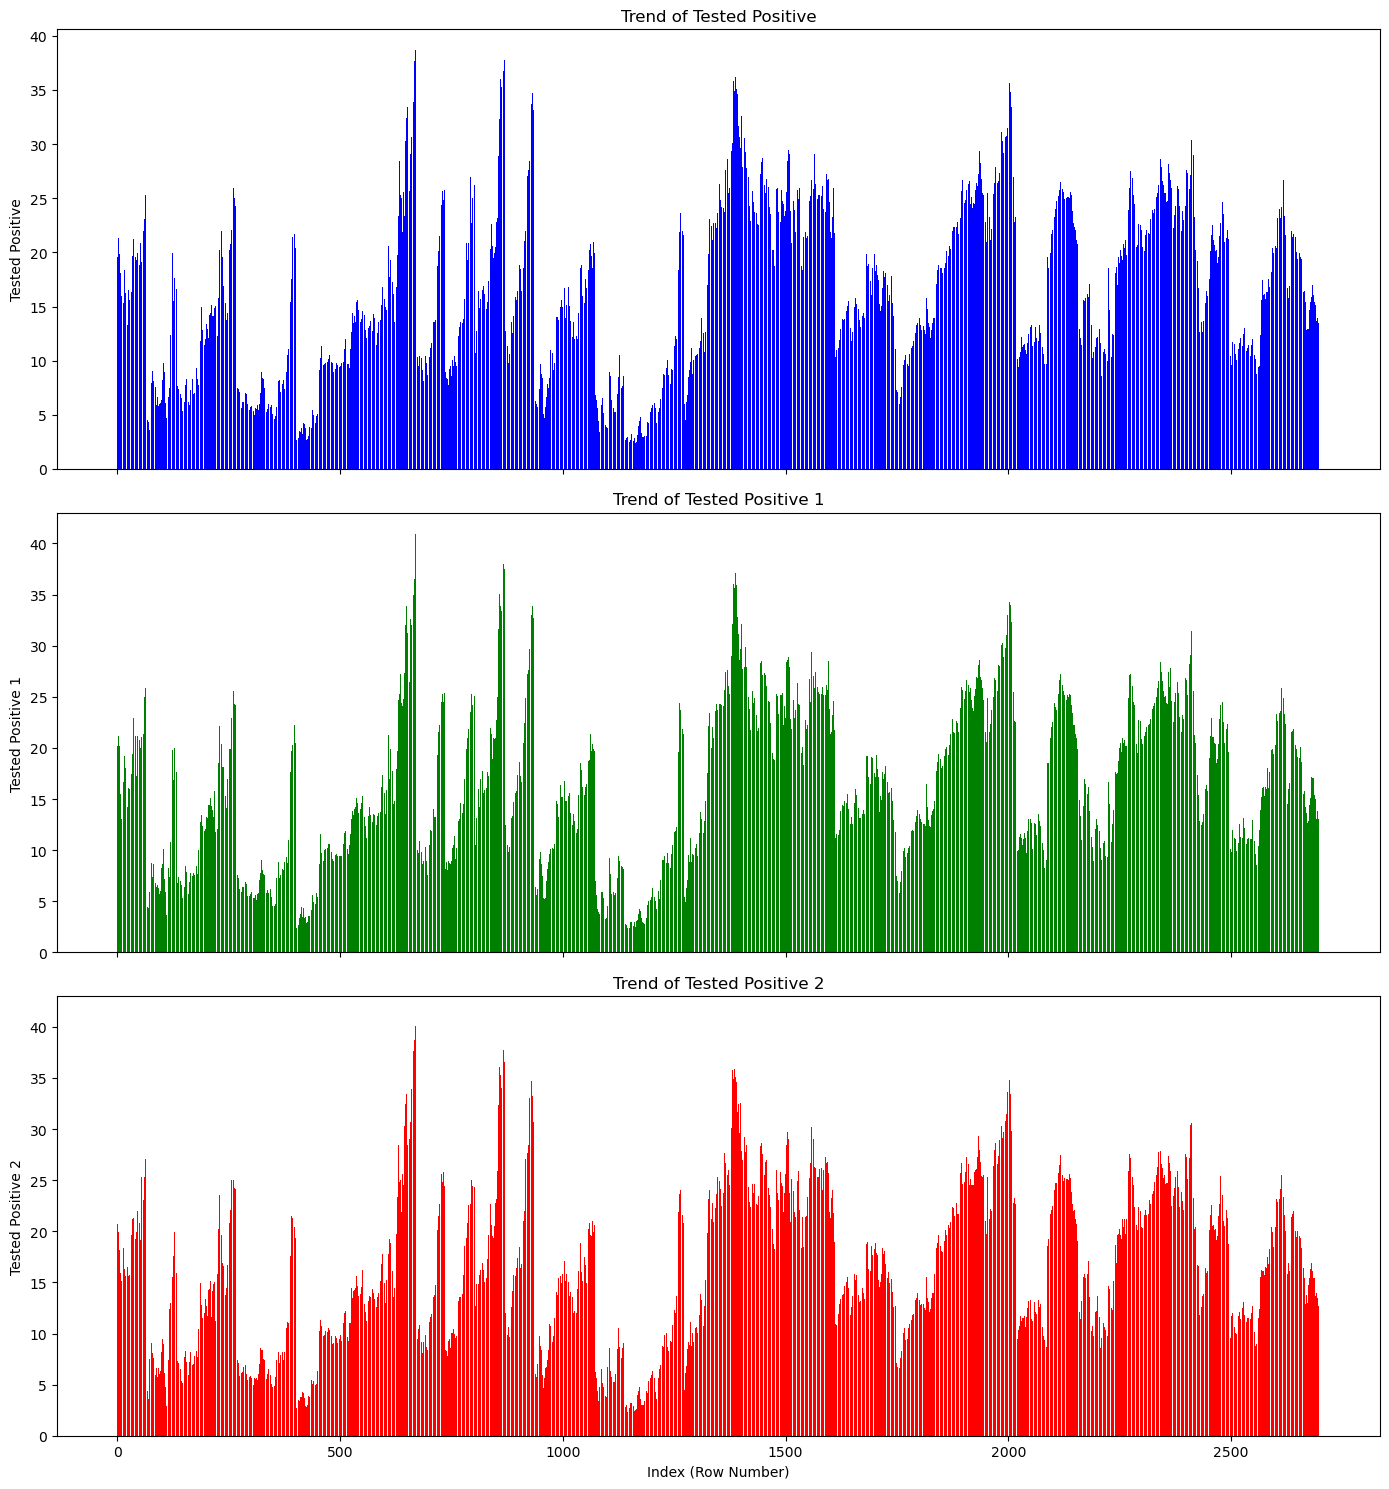

In [5]:
import matplotlib.pyplot as plt

# Set up a figure with 3 subplots
fig, axs = plt.subplots(3, 1, figsize=(14, 15), sharex=True)

# Plot for tested_positive
axs[0].bar(data_frame_train.index, data_frame_train['tested_positive'], color='b')
axs[0].set_title('Trend of Tested Positive')
axs[0].set_ylabel('Tested Positive')

# Plot for tested_positive.1
axs[1].bar(data_frame_train.index, data_frame_train['tested_positive.1'], color='g')
axs[1].set_title('Trend of Tested Positive 1')
axs[1].set_ylabel('Tested Positive 1')

# Plot for tested_positive.2
axs[2].bar(data_frame_train.index, data_frame_train['tested_positive.2'], color='r')
axs[2].set_title('Trend of Tested Positive 2')
axs[2].set_xlabel('Index (Row Number)')
axs[2].set_ylabel('Tested Positive 2')

# Adjust layout
plt.tight_layout()
plt.show()

from the above trends it is evidenet that all the 3 days the positive rate is same

it is shown that we dont have coloumn named **tested_positive.2** in test data, we have to predict this feature data using ANN

# pre-processing

In [6]:

null_values = data_frame_test.isnull().sum()

# To display only columns with missing values
missing_columns = null_values[null_values > 0]

print("Null values in each column:")
print(missing_columns)


Null values in each column:
Series([], dtype: int64)


In [7]:
null_values = data_frame_train.isnull().sum()

# To display only columns with missing values
missing_columns = null_values[null_values > 0]

print("Null values in each column:")
print(missing_columns)

Null values in each column:
Series([], dtype: int64)


# feature selection

using the correlation finding the features which has most effect to predict the target coloumn.

In [8]:
import pandas as pd

correlation = data_frame_train.corr()['tested_positive.2'].sort_values(ascending=False)
print(correlation)


tested_positive.2    1.000000
tested_positive.1    0.991012
tested_positive      0.981165
hh_cmnty_cli         0.879724
hh_cmnty_cli.1       0.879438
                       ...   
shop.1              -0.412705
shop.2              -0.415130
public_transit      -0.448360
public_transit.1    -0.449079
public_transit.2    -0.450436
Name: tested_positive.2, Length: 95, dtype: float64


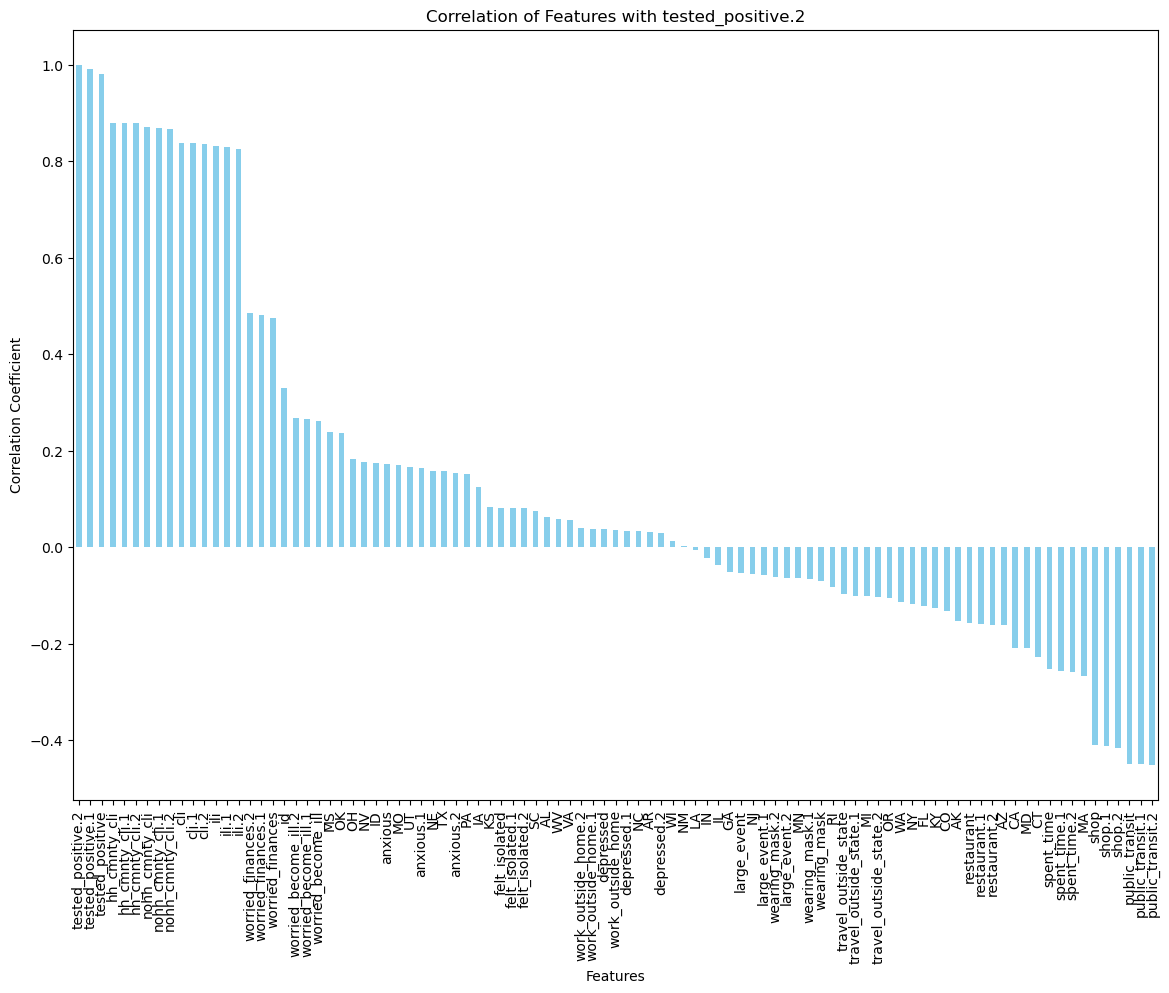

In [9]:
import matplotlib.pyplot as plt

# Plot the correlation values
plt.figure(figsize=(14, 10))
correlation = data_frame_train.corr()['tested_positive.2'].sort_values(ascending=False)

# Bar chart for correlation values
correlation.plot(kind='bar', color='skyblue')
plt.title('Correlation of Features with tested_positive.2')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Features')
plt.show()


In [10]:
# Set a threshold for feature selection
threshold = 0.5

# Select features with absolute correlation above the threshold
important_features = correlation[abs(correlation) > threshold].index.tolist()

# Drop the target variable from the list of features
important_features.remove('tested_positive.2')

print("Selected Important Features:")
print(important_features)


Selected Important Features:
['tested_positive.1', 'tested_positive', 'hh_cmnty_cli', 'hh_cmnty_cli.1', 'hh_cmnty_cli.2', 'nohh_cmnty_cli', 'nohh_cmnty_cli.1', 'nohh_cmnty_cli.2', 'cli', 'cli.1', 'cli.2', 'ili', 'ili.1', 'ili.2']


# model building

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt


def rmse(predictions, targets):
    return torch.sqrt(((predictions - targets) ** 2).mean())

# PyTorch model
class DNNModel(nn.Module):
    def __init__(self):
        super(DNNModel, self).__init__()
        self.fc1 = nn.Linear(X_train_scaled.shape[1], 14)
        self.fc2 = nn.Linear(14, 10)
        self.fc3 = nn.Linear(10, 8)
        self.fc4 = nn.Linear(8, 4)
        self.out = nn.Linear(4, 1)
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()
        self.l2_reg = 0.01

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.relu(self.fc4(x))
        x = self.dropout(x)
        x = self.out(x)
        return x


X_train = data_frame_train[important_features]
y_train = data_frame_train['tested_positive.2']
X_test = data_frame_test[important_features]

# Split training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Set up the scaler and scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(np.array(y_train), dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(np.array(y_val), dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# Create DataLoader for batch training
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=35, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=35, shuffle=False)

# Initialize the model
model = DNNModel()

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), weight_decay=model.l2_reg)

# Early stopping parameters
patience = 8
best_loss = float('inf')
counter = 0

# Lists to store RMSE values for plotting
train_rmse_list = []
val_rmse_list = []

# Training loop
epochs = 100
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Calculate RMSE for training data
    train_rmse = rmse(model(X_train_tensor), y_train_tensor).item()
    train_rmse_list.append(train_rmse)

    # Validation step
    model.eval()
    with torch.no_grad():
        val_rmse = rmse(model(X_val_tensor), y_val_tensor).item()
        val_rmse_list.append(val_rmse)

    print(f'Epoch {epoch+1}, Train RMSE: {train_rmse}, Val RMSE: {val_rmse}')
    
    # Early stopping 
    if val_rmse < best_loss:
        best_loss = val_rmse
        counter = 0
        best_model_state = model.state_dict()
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            model.load_state_dict(best_model_state)
            break



Epoch 1, Train RMSE: 17.185325622558594, Val RMSE: 17.146108627319336
Epoch 2, Train RMSE: 14.585280418395996, Val RMSE: 14.042701721191406
Epoch 3, Train RMSE: 12.303887367248535, Val RMSE: 10.132414817810059
Epoch 4, Train RMSE: 11.034378051757812, Val RMSE: 8.55722427368164
Epoch 5, Train RMSE: 10.634148597717285, Val RMSE: 7.986420154571533
Epoch 6, Train RMSE: 9.872945785522461, Val RMSE: 7.093023300170898
Epoch 7, Train RMSE: 9.283916473388672, Val RMSE: 5.557028770446777
Epoch 8, Train RMSE: 8.92841911315918, Val RMSE: 5.4098639488220215
Epoch 9, Train RMSE: 8.7761812210083, Val RMSE: 4.758159637451172
Epoch 10, Train RMSE: 8.321611404418945, Val RMSE: 4.873087406158447
Epoch 11, Train RMSE: 8.430998802185059, Val RMSE: 4.638102054595947
Epoch 12, Train RMSE: 8.433584213256836, Val RMSE: 4.7340192794799805
Epoch 13, Train RMSE: 8.52890682220459, Val RMSE: 4.264059543609619
Epoch 14, Train RMSE: 8.362344741821289, Val RMSE: 4.543144226074219
Epoch 15, Train RMSE: 7.78465938568115

# prediction

In [13]:
# Test the model on the test data
model.eval()
with torch.no_grad():
    y_test_pred = model(X_test_tensor)




# model summary

In [14]:
from torchsummary import summary

# Initialize the model
model = DNNModel()

# Print model summary
summary(model, input_size=(X_train_tensor.shape[1],))



----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 14]             210
              ReLU-2                   [-1, 14]               0
           Dropout-3                   [-1, 14]               0
            Linear-4                   [-1, 10]             150
              ReLU-5                   [-1, 10]               0
           Dropout-6                   [-1, 10]               0
            Linear-7                    [-1, 8]              88
              ReLU-8                    [-1, 8]               0
           Dropout-9                    [-1, 8]               0
           Linear-10                    [-1, 4]              36
             ReLU-11                    [-1, 4]               0
          Dropout-12                    [-1, 4]               0
           Linear-13                    [-1, 1]               5
Total params: 489
Trainable params: 489

# evaluation and prediction visualisation

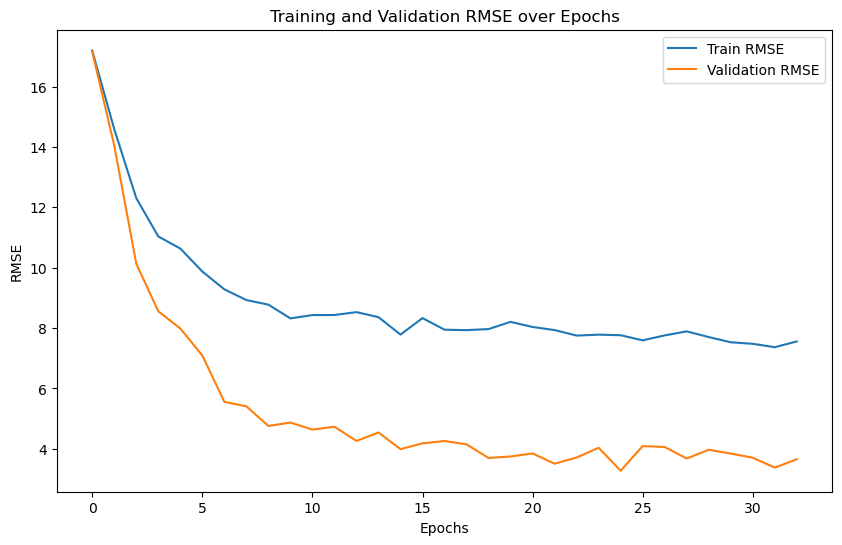

In [16]:
import matplotlib.pyplot as plt

# Plot training and validation RMSE across epochs
plt.figure(figsize=(10,6))
plt.plot(train_rmse_list, label='Train RMSE')
plt.plot(val_rmse_list, label='Validation RMSE')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('Training and Validation RMSE over Epochs')
plt.legend()
plt.show()



In [17]:
print("Predictions on test data:")
print(y_test_pred)


Predictions on test data:
tensor([[17.2681],
        [ 6.5825],
        [ 6.5012],
        [ 9.6317],
        [ 6.5784],
        [21.4542],
        [21.6713],
        [ 7.7225],
        [ 9.5795],
        [ 9.8747],
        [14.5150],
        [18.1206],
        [17.8650],
        [10.6365],
        [16.6125],
        [15.2096],
        [23.9463],
        [ 7.7480],
        [18.0437],
        [ 6.6804],
        [ 7.5890],
        [19.1691],
        [15.4845],
        [12.3036],
        [10.1950],
        [22.4562],
        [20.7845],
        [22.3347],
        [ 7.6871],
        [16.4000],
        [ 8.7794],
        [ 7.4777],
        [22.6231],
        [ 9.9384],
        [17.7214],
        [24.5494],
        [10.5442],
        [ 7.5381],
        [12.2804],
        [ 7.8760],
        [12.6147],
        [ 6.9237],
        [ 7.8937],
        [15.0235],
        [ 7.3860],
        [12.3765],
        [11.7837],
        [ 6.7641],
        [ 7.5258],
        [13.0153],
        [13.5650],
     